# **Laboratorio 3:** Agrupación y agregación

### Cargar las librerías

Importar la librería Pandas

In [1]:
import pandas as pd 

datos = {
    'Producto': ['Laptop', 'Teclado', 'Laptop', 'Monitor', 'Teclado', 'Mouse', 'Monitor', 'Laptop'],
    'Categoria': ['Electrónica', 'Accesorios', 'Electrónica', 'Electrónica', 'Accesorios', 'Accesorios', 'Electrónica', 'Electrónica'],
    'Region': ['Norte', 'Sur', 'Norte', 'Este', 'Sur', 'Norte', 'Este', 'Sur'],
    'Precio_Unitario': [1200, 45, 1100, 300, 50, 25, 320, 1250],
    'Cantidad': [2, 10, 1, 4, 12, 60, 2, 9],
    'Sueldo': [4500, 3200, 6000, 2800, 5200, 1900, 4100, 7500]
}

df = pd.DataFrame(datos)

#### Agrupación simple
La cateogoría contiene 2 valores, accesorios y electronica; en sueldo los relaciona y crea una lista con nombre categoria 
y con los elementos coincidentes de sueldo


In [4]:
df.groupby('Categoria')['Sueldo'].mean()

Categoria
Accesorios     3433.333333
Electrónica    4980.000000
Name: Sueldo, dtype: float64

### Agrupación avanzada 
con .agg, usar para una categoria, varias columnas con números

In [9]:
resumen_region = df.groupby('Region').agg({

    'Precio_Unitario': 'mean', # sacar el promedio de cada seccion de region de su respectivo precio_unitario
    'Cantidad': 'sum' # hallar la suma de cada sección de region con su respectiva cantidad


})

print(resumen_region)

        Precio_Unitario  Cantidad
Region                           
Este         310.000000         6
Norte        775.000000        63
Sur          448.333333        31


In [ ]:
# Aplicar métricas específicas por columna
resumen = df.groupby('Categoria').agg({
    'Precio_Unitario': ['mean', 'min', 'max'], # Tres métricas para Precio
    'Cantidad': 'sum'             # Suma para Cantidad
})
print(resumen)

            Precio_Unitario            Cantidad
                       mean  min   max      sum
Categoria                                      
Accesorios             40.0   25    50       82
Electrónica           834.0  300  1250       18


1. Promedio por Producto:

Usa .groupby() para calcular el promedio (mean) de la columna Precio_Unitario de cada Producto.

In [9]:
df.groupby('Producto')['Precio_Unitario'].mean()

Producto
Laptop     1183.333333
Monitor     310.000000
Mouse        25.000000
Teclado      47.500000
Name: Precio_Unitario, dtype: float64

2. Total de Ventas por Región:

Agrupa por Region y calcula la suma (sum) únicamente de la columna Cantidad.

In [10]:
df.groupby('Region')['Cantidad'].sum()

Region
Este      6
Norte    63
Sur      31
Name: Cantidad, dtype: int64

3. Métricas Combinadas:

Usa .groupby('Categoria') junto con .agg() para calcular al mismo tiempo:

El precio máximo (max) de la columna Precio_Unitario.

El promedio (mean) de la columna Sueldo.

In [ ]:
df.groupby('Categoria').agg({

    'Precio_Unitario' : 'max',
    'Sueldo' : 'mean'

})

,Precio_Unitario,Sueldo
Region,,
Este,320,3450.000000
Norte,1200,4133.333333
Sur,1250,5300.000000


4. Ejercicio Desafío de la Clase 3:

Agrupación y Gráfico Combinados:

Agrupa el DataFrame por Producto, calcula la suma de la Cantidad vendida de cada uno, y al resultado aplícale directamente un .plot(kind='bar') para visualizar qué producto se vendió más.

<Axes: title={'center': 'Ventas del producto'}, xlabel='Producto', ylabel='Cantidad'>

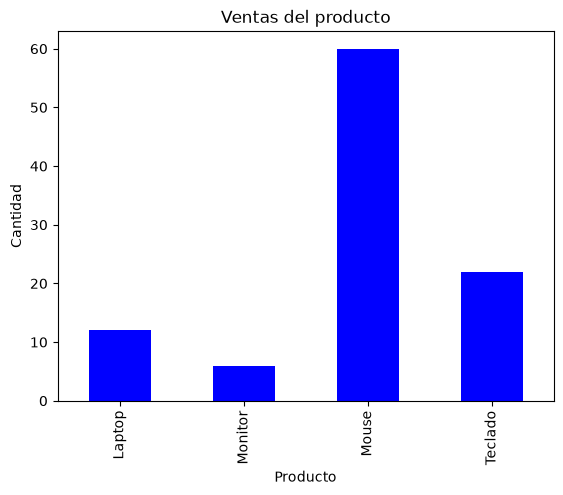

In [20]:
resumen_producto = df.groupby('Producto')['Cantidad'].sum()

resumen_producto.plot(

    kind = 'bar',
    title = 'Ventas del producto',
    xlabel= 'Producto',
    ylabel= 'Cantidad',
    color = 'blue'
    
)